# Sweep analysis (v2 — clean loader)

Predicate-based loader (`load_runs(where=...)`) replaces the scope-string + filter_fn pattern from `sweep_analysis.ipynb`. One audit cell at the top reports orphans, deprecated groups, unknown optimizers, and lr-pinning. Every other cell is a one-line `load_runs` call describing what it wants.

Scoped to two headline panels (Pre-Adam preconditioning + Adam→spectral/polar) across r ∈ {16, 64, 128, 256}. Other sections will migrate cell-by-cell in a follow-up; the v1 notebook keeps working in the meantime via thin shims.

All numbers are single-seed at the canonical 2k-step horizon.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs, inventory_runs, render_inventory
from lora_playground.plot_utils import (
    OPTIM_COLORS, OPTIM_MARKERS, standard_sweep_figure,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Audit

Single source of truth for "what could be silently wrong." Each line is a structural fact — orphaned manifest, self-deprecated group, optimizer in logs but missing from `OPTIM_COLORS`, or a (optimizer, rank, mult) cell whose best lr equals the boundary of the swept range. No threshold-based heuristics.

In [2]:
inv = inventory_runs("../logs")
print(render_inventory(inv))

Loaded 59 of 60 groups on disk.

UNKNOWN OPTIMIZERS (3) — in logs but missing from OPTIM_COLORS, will be dropped by any cell that filters on it:
  kfac-lora
  svd-cumulative-adamw
  svd-step-adamw

Coverage: 60 (optimizer, rank, mult) cells
PINNED at lr-range boundary (16) — extension sweep recommended:
  adam-lin-lora                     r=2           best_lr=1e-03 (final=0.7914)   swept=['3e-04', '1e-03'] → pinned_high
  adam-lin-lora                     r=4           best_lr=1e-03 (final=0.7782)   swept=['3e-04', '1e-03'] → pinned_high
  adam-lin-lora-matrix              r=64          best_lr=1e-03 (final=0.7690)   swept=['3e-04', '1e-03'] → pinned_high
  adam-product-muon-lora            r=16   m=4    best_lr=3e-04 (final=0.8271)   swept=['3e-04', '1e-03', '3e-03', '1e-02'] → pinned_low
  adam-scaled-lora                  r=2           best_lr=1e-03 (final=0.7909)   swept=['3e-04', '1e-03'] → pinned_high
  adam-scaled-lora                  r=4           best_lr=1e-03 (final=0.7777)

## Pre-Adam preconditioning (geometry → Adam)

`adam-lin-lora` and `adam-scaled-lora` apply Adam to the geometrically-preconditioned gradient. AdamW baseline is overlaid in black.

  [filtered diverged] adam-scaled-lora η=1e-02 max=2.269 final=1.665
  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [clipped from left panel y_cap=0.908] 2 run(s):
    adam-lin-lora η=1e-02 final=1.3112
    adamw η=3e-03 final=1.0223


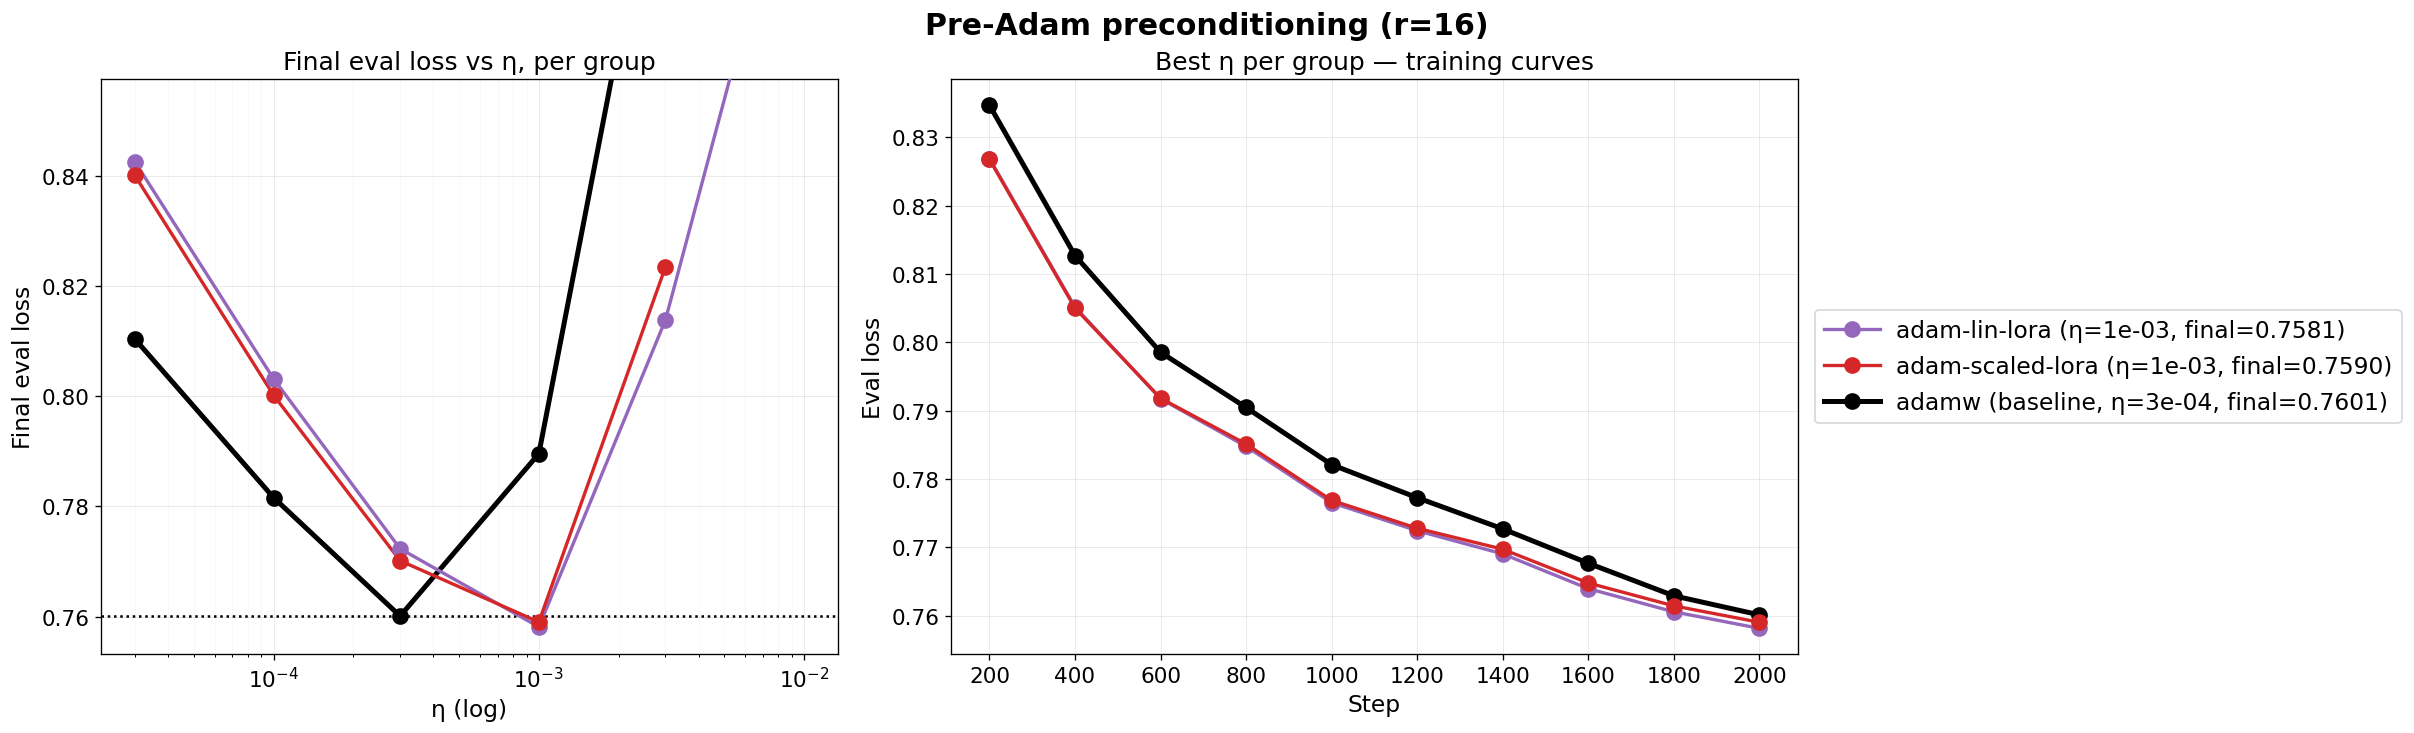

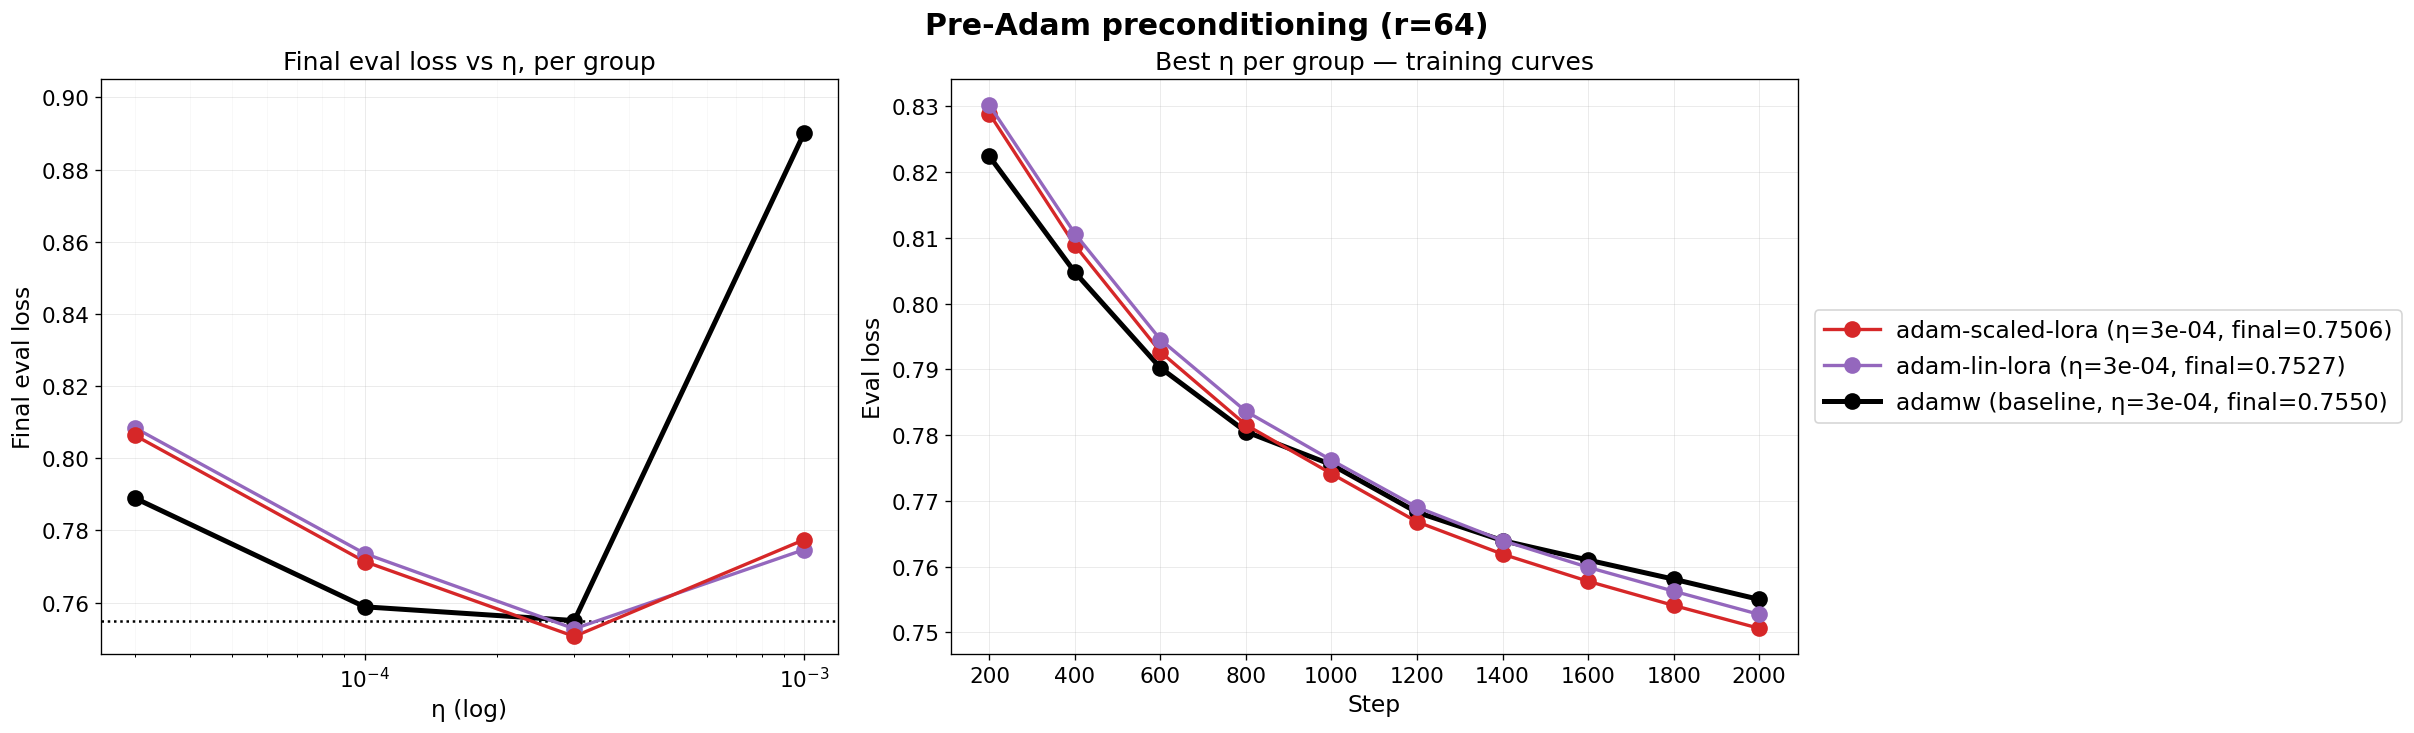

  [clipped from left panel y_cap=0.898] 1 run(s):
    adamw η=1e-03 final=1.0116


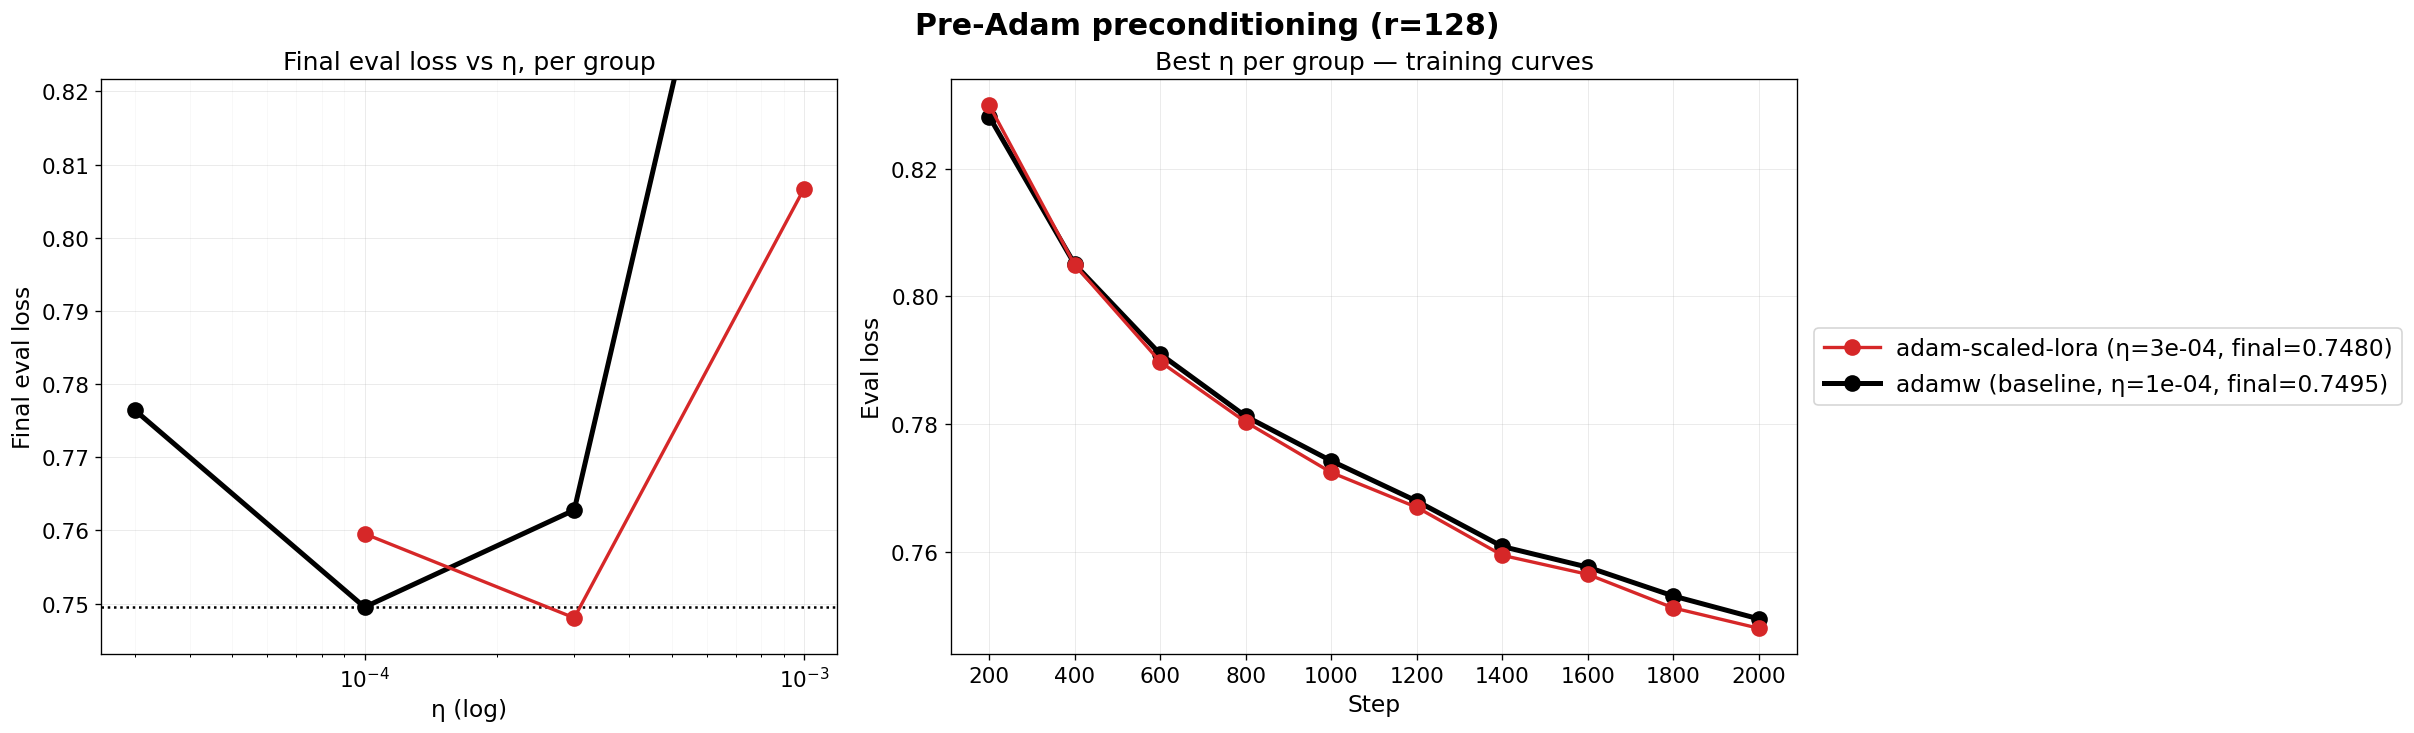

  [clipped from left panel y_cap=0.893] 1 run(s):
    adamw η=1e-03 final=1.2023


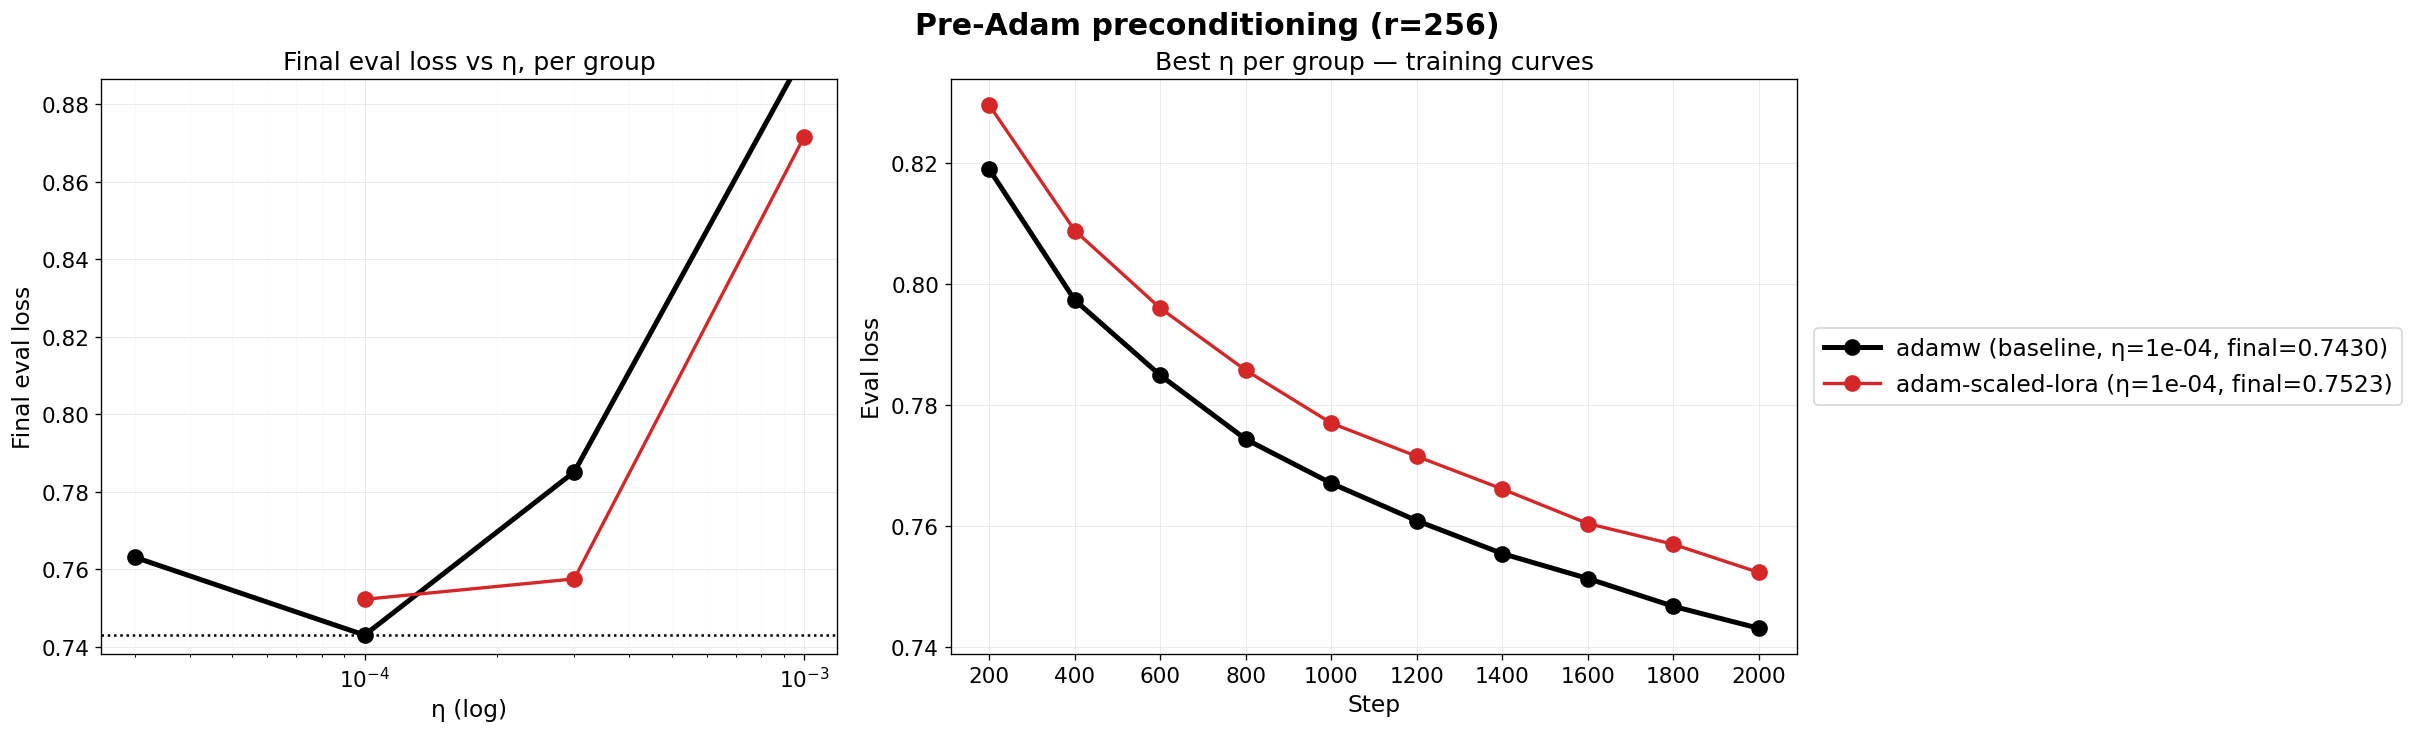

In [3]:
PRE_ADAM = ["adamw", "adam-lin-lora", "adam-scaled-lora"]

for r in (16, 64, 128, 256):
    runs = load_runs(
        where={"optimizer": PRE_ADAM, "lora_r": r, "lora_plus_multiplier": 1.0},
        logs_root="../logs",
    )
    if not runs:
        continue
    standard_sweep_figure(
        runs,
        group_key_fn=lambda c: c["optimizer"],
        color_map=OPTIM_COLORS,
        marker_map=OPTIM_MARKERS,
        reference_runs=runs,
        suptitle=f"Pre-Adam preconditioning (r={r})",
    )
    plt.show()

## Adam → spectral/polar correction (the headline)

`adam-muon-lora`, `adam-polar-product-lora`, `adamuon-lora`, `adamuon-polar-product-lora`: Adam runs first; the polar/spectral correction is applied to the Adam direction. AdamW baseline is overlaid in black.

  [filtered diverged] adam-polar-product-lora η=1e-02 max=1.977 final=1.651
  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [filtered partial from left panel] 3 run(s) below min_step=2000:
    adam-muon-lora η=1e-04         step=500 final-so-far=1.0742
    adam-muon-lora η=3e-02         step=500 final-so-far=0.8920
    adam-muon-lora η=3e-04         step=500 final-so-far=0.9272
  [clipped from left panel y_cap=0.905] 2 run(s):
    adam-polar-product-lora η=3e-03 final=0.9997
    adamw η=3e-03 final=1.0223


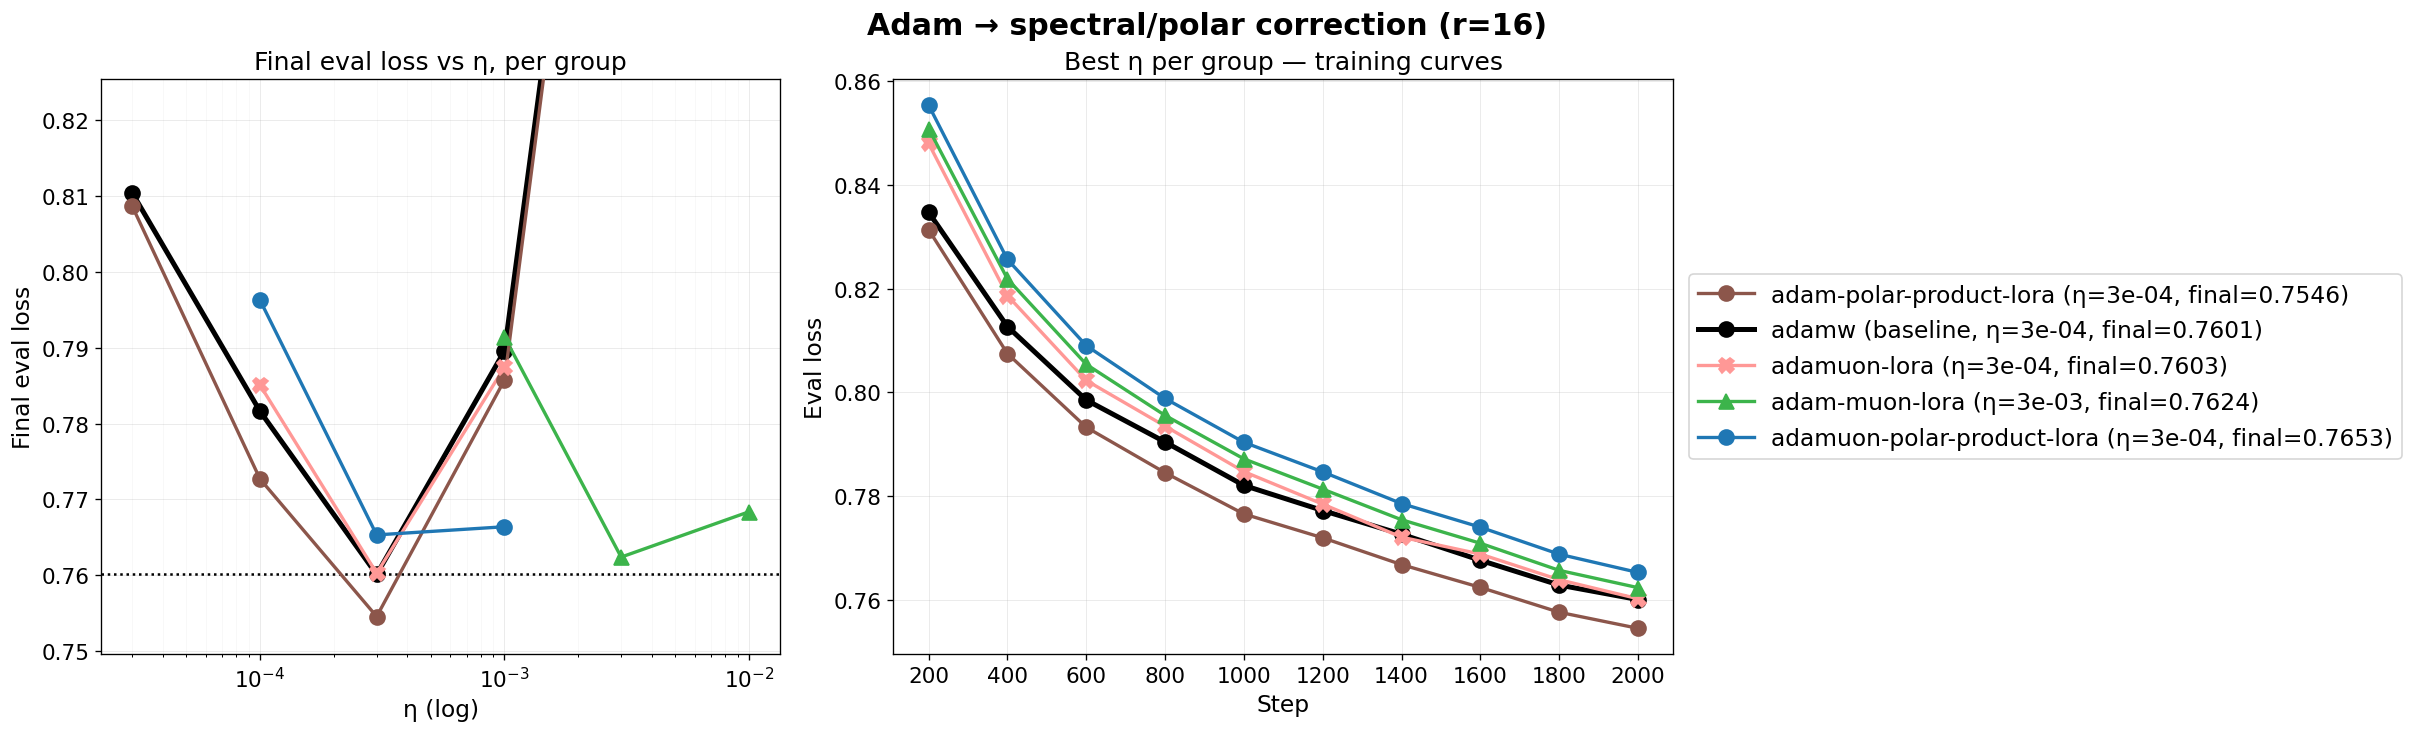

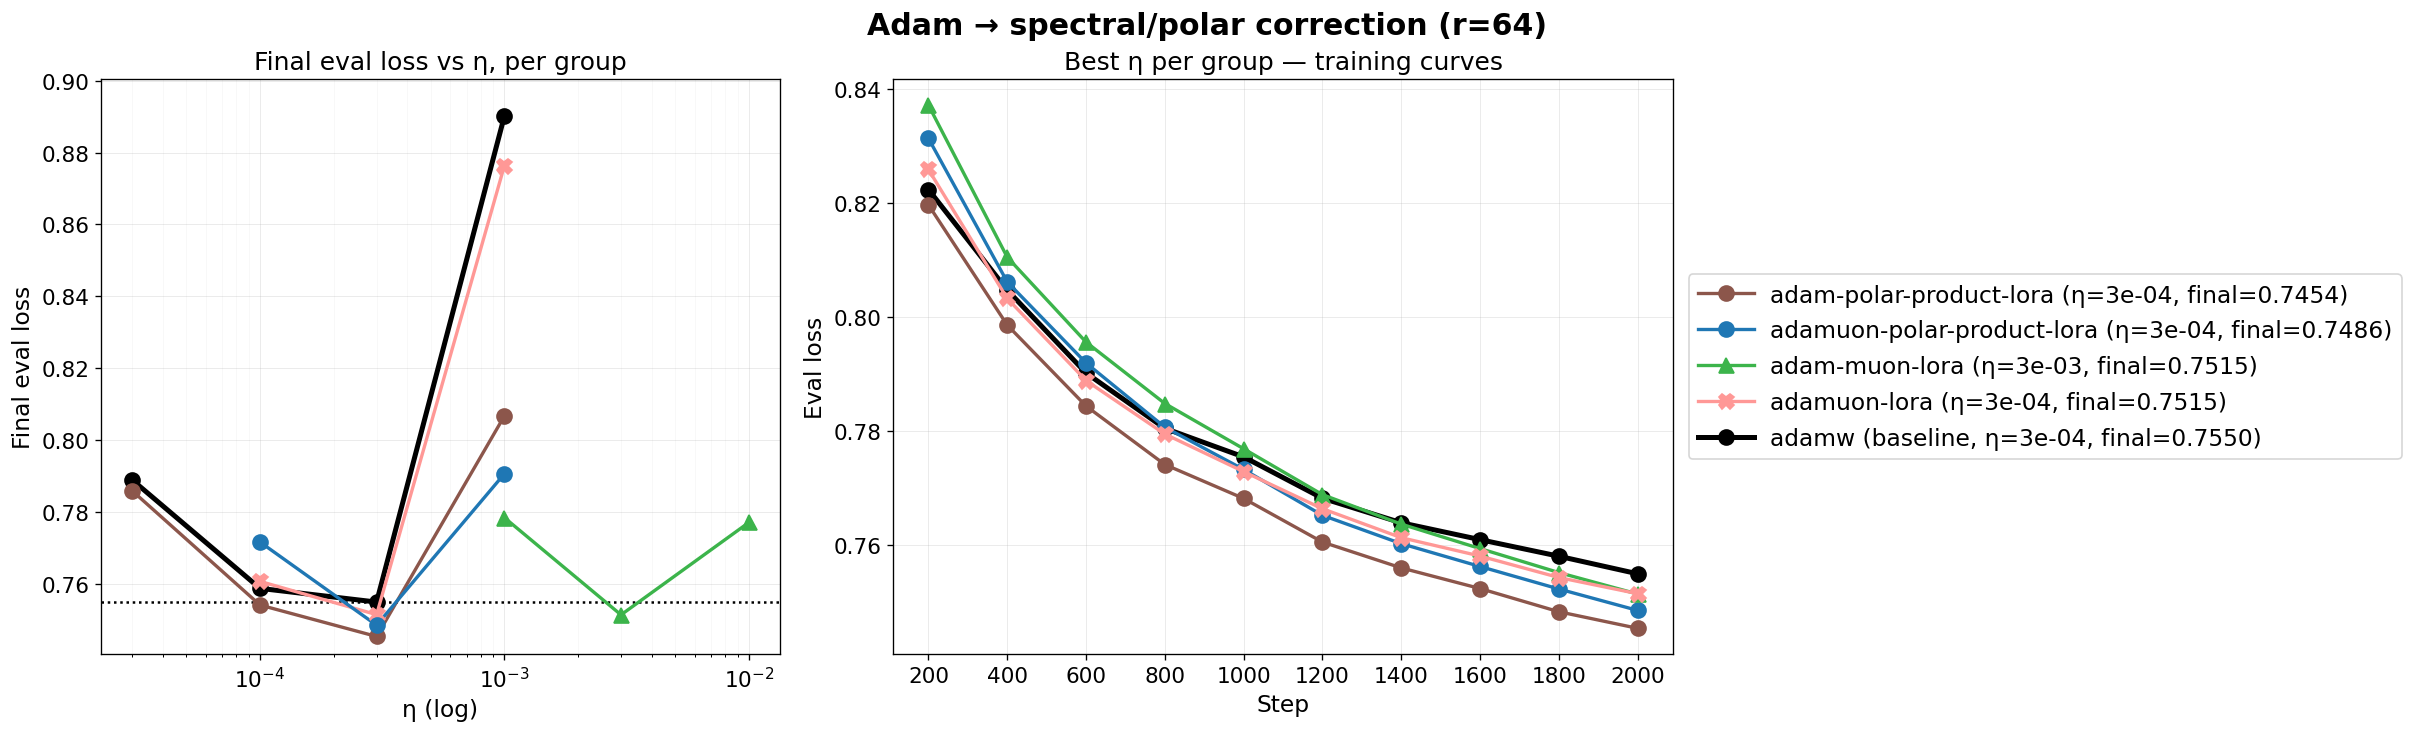

  [filtered partial from left panel] 1 run(s) below min_step=2000:
    adam-polar-product-lora η=3e-05 step=600 final-so-far=0.8212
  [clipped from left panel y_cap=0.894] 1 run(s):
    adamw η=1e-03 final=1.0116


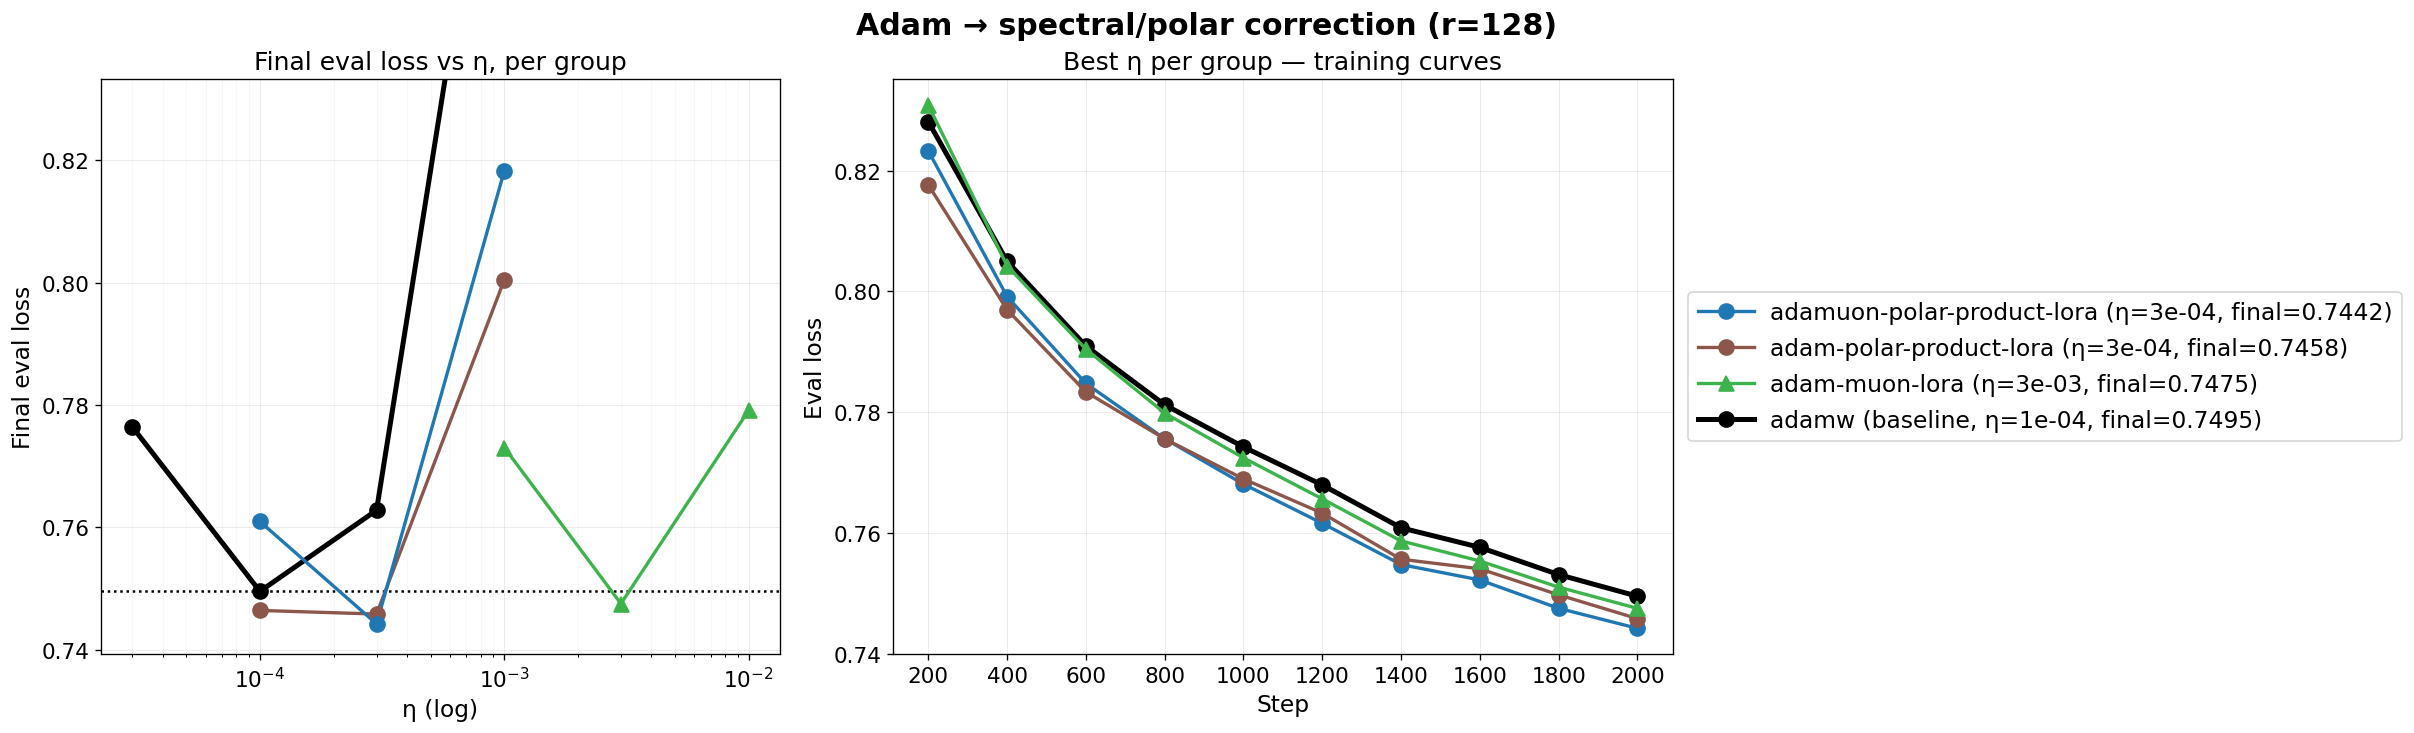

  [filtered partial from left panel] 1 run(s) below min_step=2000:
    adam-polar-product-lora η=3e-05 step=200 final-so-far=0.8489
  [clipped from left panel y_cap=0.891] 1 run(s):
    adamw η=1e-03 final=1.2023


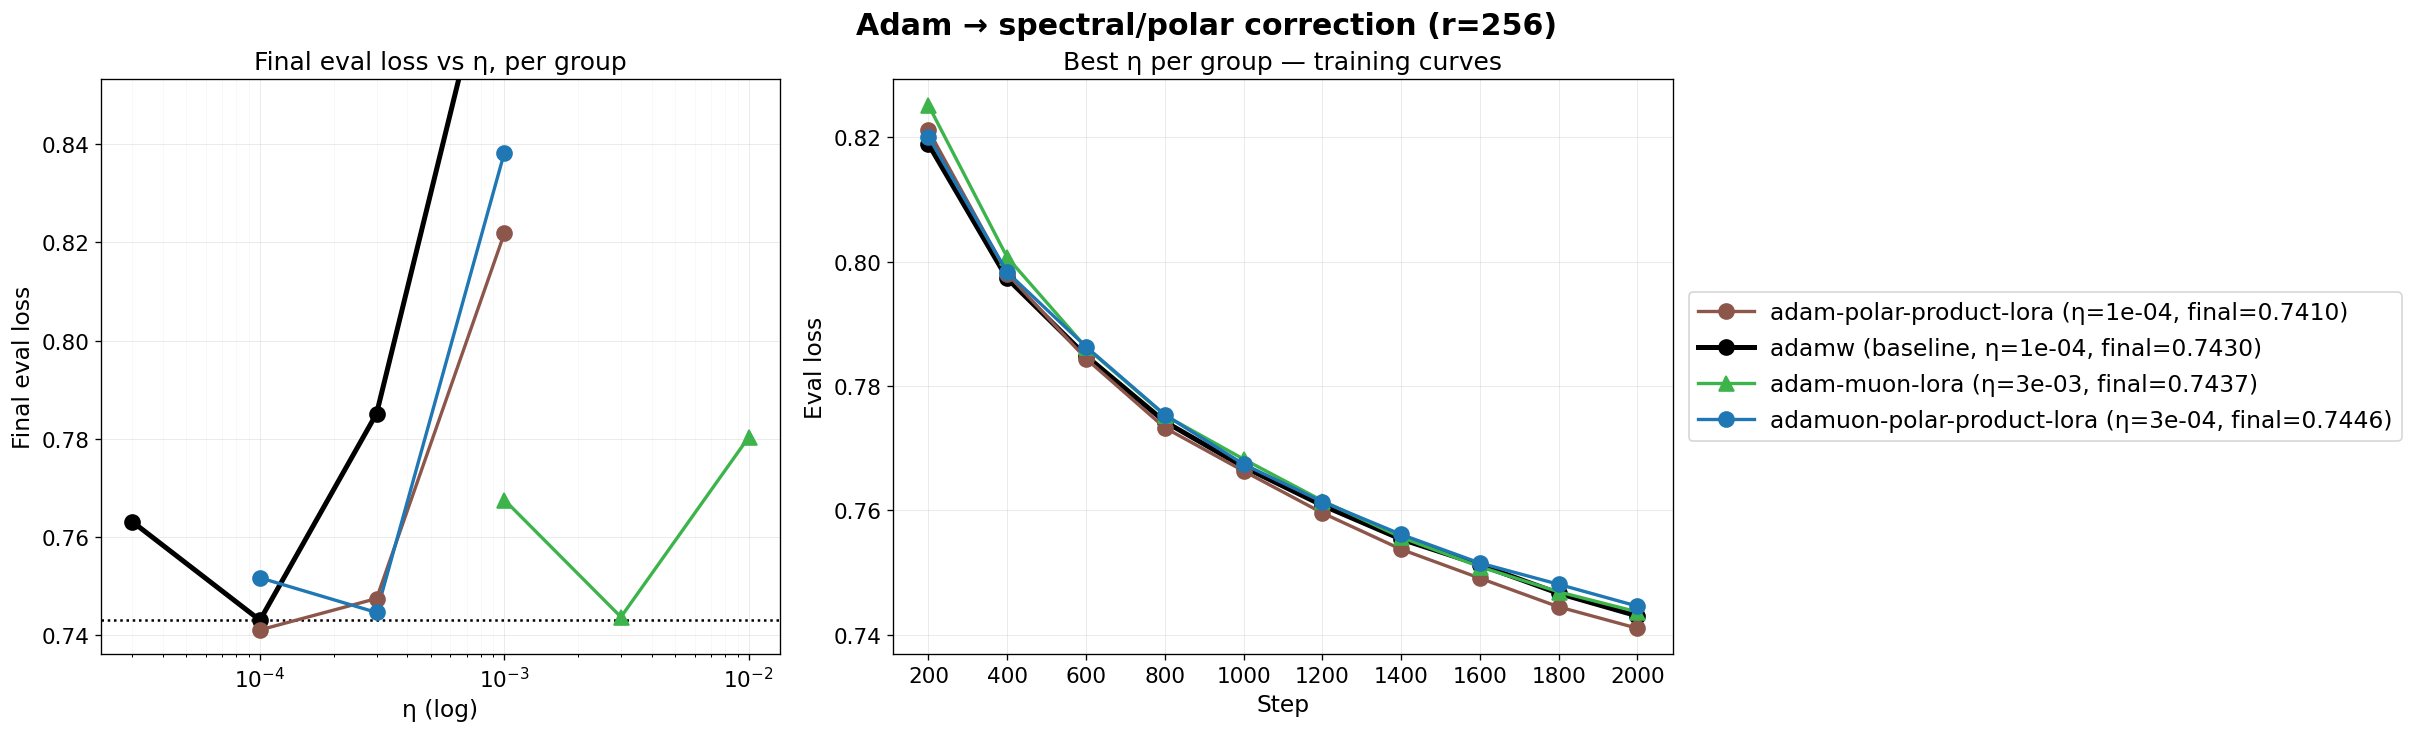

In [4]:
POLAR_FAMILY = [
    "adamw",
    "adam-muon-lora",
    "adam-polar-product-lora",
    "adamuon-lora",
    "adamuon-polar-product-lora",
]

for r in (16, 64, 128, 256):
    runs = load_runs(
        where={"optimizer": POLAR_FAMILY, "lora_r": r, "lora_plus_multiplier": 1.0},
        logs_root="../logs",
    )
    if not runs:
        continue
    standard_sweep_figure(
        runs,
        group_key_fn=lambda c: c["optimizer"],
        color_map=OPTIM_COLORS,
        marker_map=OPTIM_MARKERS,
        reference_runs=runs,
        suptitle=f"Adam \u2192 spectral/polar correction (r={r})",
    )
    plt.show()